In [71]:
import pandas as pd


## Parameters

In [72]:
# Parameters
flanks = 500
kmer_dissim_threshold = 0.8

# Codes for annotation
code_pan =      [1, 1, 0, 0, 0, 0, 0]
code_pongo =    [0, 0, 0, 0, 1, 1, 0]
code_bch =      [1, 1, 1, 0, 0, 0, 0]
code_bchg =     [1, 1, 1, 1, 0, 0, 0]
code_bchgo =    [1, 1, 1, 1, 1, 1, 0]
code_bchgos =   [1, 1, 1, 1, 1, 1, 1]

# Mapping the codes to annotations
codes_map = {
    tuple(code_pan): 'pan',
    tuple(code_pongo): 'pongo',
    tuple(code_bch): 'bch',
    tuple(code_bchg): 'bchg',
    tuple(code_bchgo): 'bchgo',
    tuple(code_bchgos): 'bchgos'
}

## Import and annotate files

In [73]:
# Matrix of NUMT presence/absence in lineages.
df = pd.read_table(f'results_{flanks}bp/species_matrix_flanks{flanks}_{kmer_dissim_threshold}.tsv')
df['NUMT_Assembly'] = df['NUMT'].str.split('_', 1).str[0]
df.insert(1, 'NUMT_Assembly', df.pop('NUMT_Assembly'))

# NUMT Blast info.
blast = pd.read_table(f"results_{flanks}bp/loci_numts.flanks{flanks}.tab")
blast['NUMT_Size'] = blast['NUMT_info'].str.split('_').str[1]
blast['NUMT_Start'] = blast['Loci'].str.split(':').str[-1].str.split('-').str[0].astype('int')
blast['NUMT_End'] = blast['Loci'].str.split(':').str[-1].str.split('-').str[1].astype('int')
blast['NUMT_size'] = abs(blast['NUMT_End'] - blast['NUMT_Start'])
blast['NUMT_PI'] = blast['NUMT_info'].str.split('_').str[2].str.split(',').str[0].str[:-1].astype('int')

# Annotate matrix with NUMT size and Percent Identity to mtDNA.
df = pd.merge( df, blast[['NUMT','NUMT_Size','NUMT_PI']] )

blast

,Query_Species,NUMT,NUMT_info,Loci,NUMT_Size,NUMT_Start,NUMT_End,NUMT_size,NUMT_PI
0,mGorGor1,mGorGor1_numt1,NUMT_284bp_74%,+::chr10_mat_hsa12:23259700-23259984,284bp,23259700,23259984,284,74
1,mGorGor1,mGorGor1_numt2,NUMT_212bp_67%,+::chr10_mat_hsa12:23260126-23260338,212bp,23260126,23260338,212,67
2,mGorGor1,mGorGor1_numt3,NUMT_460bp_66%,+::chr10_mat_hsa12:23260619-23261079,460bp,23260619,23261079,460,66
3,mGorGor1,mGorGor1_numt4,NUMT_240bp_67%,-::chr10_mat_hsa12:23277127-23277367,240bp,23277127,23277367,240,67
4,mGorGor1,mGorGor1_numt5,NUMT_275bp_69%,+::chr10_mat_hsa12:24952757-24953032,275bp,24952757,24953032,275,69
...,...,...,...,...,...,...,...,...,...
5376,CHM13,CHM13_numt776,NUMT_955bp_75%,-::NC_060948.1:11353453-11354408,955bp,11353453,11354408,955,75
5377,CHM13,CHM13_numt777,NUMT_1345bp_75%,+::NC_060948.1:11354421-11355766,1345bp,11354421,11355766,1345,75
5378,CHM13,CHM13_numt778,NUMT_516bp_83%,+::NC_060948.1:11355830-11356346,516bp,11355830,11356346,516,83
5379,CHM13,CHM13_numt779,NUMT_140bp_80%,-::NC_060948.1:11666771-11666911,140bp,11666771,11666911,140,80


## Classify NUMTs by lineages

In [74]:
# Create a new column by matching the row values to the Lineage codes
df['annotation'] = df[['Bonobo', 'Chimpanzee', 'Human', 'Gorilla', 'Sorang', 'Borang', 'Siamang']].apply(tuple, axis=1).map(codes_map).fillna('unknown')

# Create a function to determine the annotation
def annotate_row(row):
    row_values = row[['Bonobo', 'Chimpanzee', 'Human', 'Gorilla', 'Sorang', 'Borang', 'Siamang']]
    if row_values.sum() == 1:
        return 'species-specific'
    else:
        return codes_map.get(tuple(row_values), 'unknown')

# Apply the annotation function to the rows
df['annotation'] = df.apply(annotate_row, axis=1)

# Boolean column for species-specific NUMTs.
df.loc[df['annotation'] == 'species-specific', 'Species_specific'] = True
df['Species_specific'] = df['Species_specific'].fillna(False)

df.describe()



,Bonobo,Chimpanzee,Human,Gorilla,Sorang,Borang,Siamang,NUMT_PI
count,5202.000000,5202.000000,5202.000000,5202.000000,5202.000000,5202.000000,5202.000000,5202.000000
mean,0.681084,0.702999,0.615340,0.628604,0.648212,0.647443,0.408689,78.653595
std,0.466101,0.456981,0.486562,0.483224,0.477574,0.477812,0.491639,7.505401
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,65.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,73.000000
50%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,77.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,83.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,100.000000


/Users/edmundo/miniconda3/envs/bioinfo/lib/python3.6/site-packages/numpy/core/_asarray.py:83: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray
  return array(a, dtype, copy=False, order=order)


<Figure size 576x432 with 0 Axes>

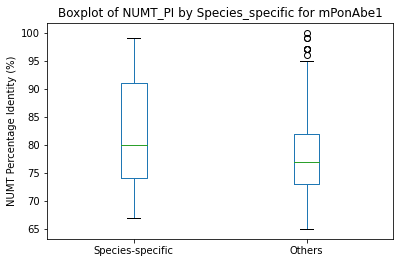

/Users/edmundo/miniconda3/envs/bioinfo/lib/python3.6/site-packages/numpy/core/_asarray.py:83: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray
  return array(a, dtype, copy=False, order=order)


<Figure size 576x432 with 0 Axes>

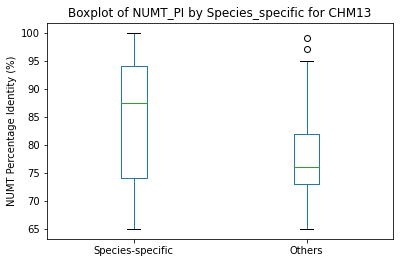

/Users/edmundo/miniconda3/envs/bioinfo/lib/python3.6/site-packages/numpy/core/_asarray.py:83: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray
  return array(a, dtype, copy=False, order=order)


<Figure size 576x432 with 0 Axes>

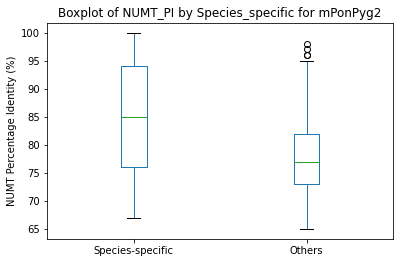

/Users/edmundo/miniconda3/envs/bioinfo/lib/python3.6/site-packages/numpy/core/_asarray.py:83: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray
  return array(a, dtype, copy=False, order=order)


<Figure size 576x432 with 0 Axes>

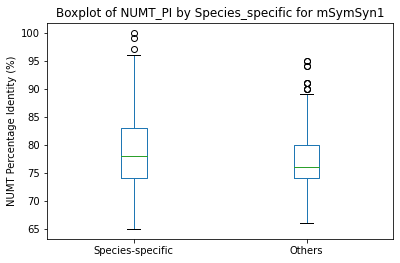

/Users/edmundo/miniconda3/envs/bioinfo/lib/python3.6/site-packages/numpy/core/_asarray.py:83: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray
  return array(a, dtype, copy=False, order=order)


<Figure size 576x432 with 0 Axes>

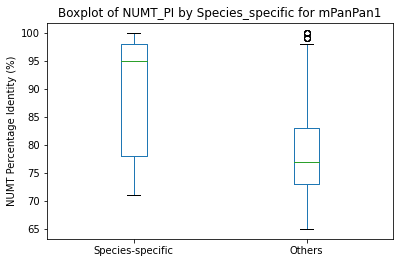

/Users/edmundo/miniconda3/envs/bioinfo/lib/python3.6/site-packages/numpy/core/_asarray.py:83: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray
  return array(a, dtype, copy=False, order=order)


<Figure size 576x432 with 0 Axes>

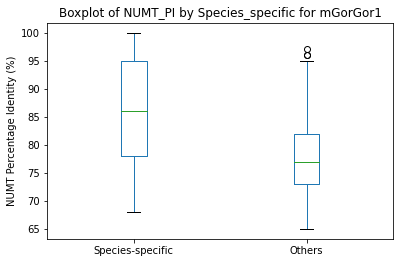

/Users/edmundo/miniconda3/envs/bioinfo/lib/python3.6/site-packages/numpy/core/_asarray.py:83: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray
  return array(a, dtype, copy=False, order=order)


<Figure size 576x432 with 0 Axes>

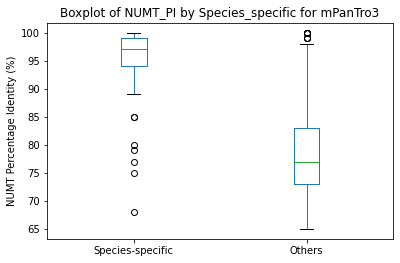

In [77]:
# Ensure 'Species_specific' is ordered as 'species-specific' first, then 'others'
df['Species_specific'] = pd.Categorical(
    df['Species_specific'].replace({True: 'Species-specific', False: 'Others'}),
    categories=['Species-specific', 'Others'],
    ordered=True
)
# Plot boxplots for each assembly
for assembly in set(df['NUMT_Assembly']):
    # Filter DataFrame for the current assembly
    filtered_df = df[df['NUMT_Assembly'] == assembly]
    
    # Create the plot
    plt.figure(figsize=(8, 6))
    filtered_df.boxplot(column='NUMT_PI', by='Species_specific', grid=False)
    plt.title(f'Boxplot of NUMT_PI by Species_specific for {assembly}')
    plt.suptitle('')  # Suppress the default title to only show the custom title
    plt.xlabel('')
    plt.ylabel('NUMT Percentage Identity (%)')
    plt.show()

/Users/edmundo/miniconda3/envs/bioinfo/lib/python3.6/site-packages/numpy/core/_asarray.py:83: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray
  return array(a, dtype, copy=False, order=order)
/Users/edmundo/miniconda3/envs/bioinfo/lib/python3.6/site-packages/numpy/core/_asarray.py:83: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray
  return array(a, dtype, copy=False, order=order)
/Users/edmundo/miniconda3/envs/bioinfo/lib/python3.6/site-packages/numpy/core/_asarray.py:83: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a 

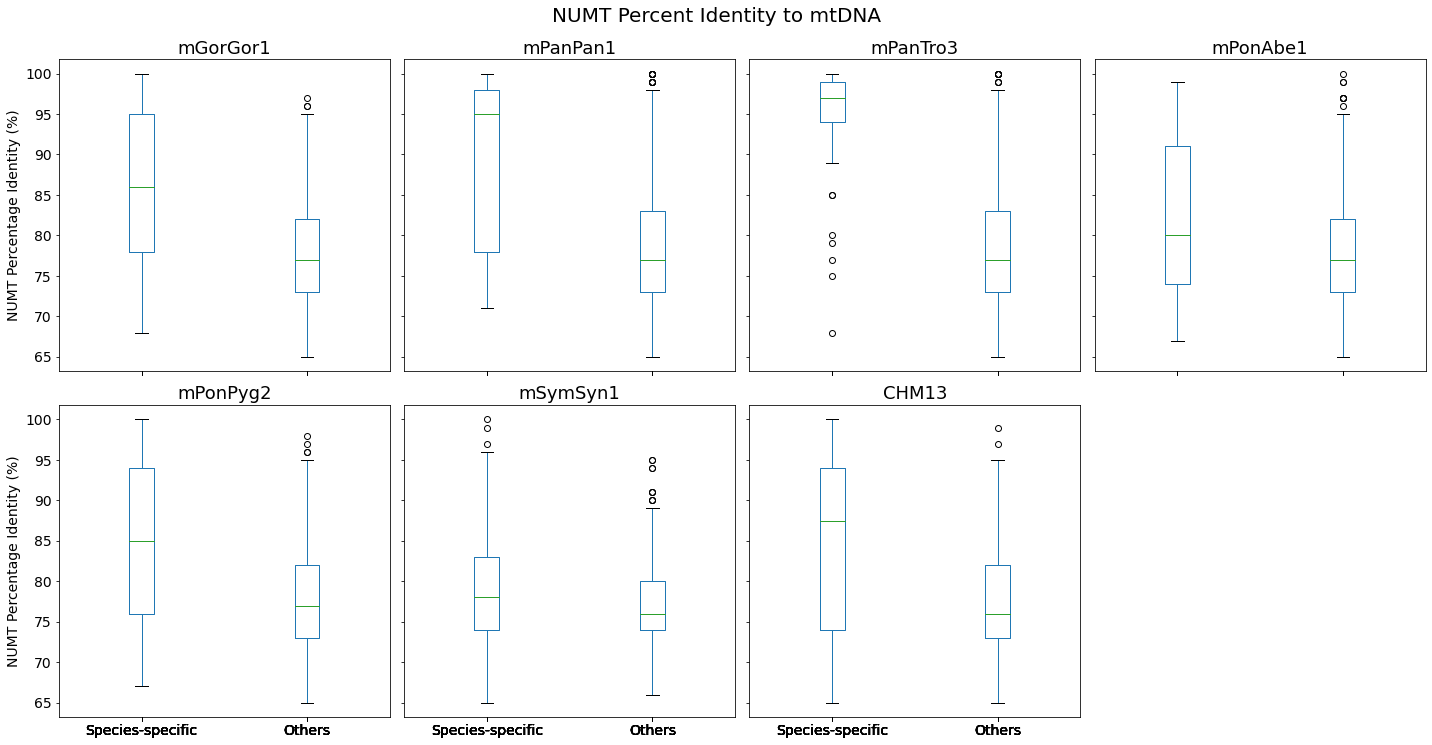

In [113]:
# Get the unique assemblies
assemblies = df['NUMT_Assembly'].unique()
num_assemblies = len(assemblies)

# Determine grid size for subplots
cols = 4  # Number of columns for subplots
rows = (num_assemblies + cols - 1) // cols  # Calculate the number of rows needed

# Create subplots
fig, axes = plt.subplots(rows, cols, figsize=(5 * cols , 5 * rows), sharex=True, sharey=True)
axes = axes.flatten()  # Flatten to easily iterate

# Plot boxplots for each assembly
for ax, assembly in zip(axes, assemblies):
    # Filter DataFrame for the current assembly
    filtered_df = df[df['NUMT_Assembly'] == assembly]
    
    # Create the plot
    filtered_df.boxplot(column='NUMT_PI', by='Species_specific', grid=False, ax=ax)
    ax.set_title(f'{assembly}', fontsize=18)
    ax.set_xlabel('')
    axes[0].set_ylabel('NUMT Percentage Identity (%)', fontsize=14)
    axes[cols].set_ylabel('NUMT Percentage Identity (%)', fontsize=14)
    ax.tick_params(axis='both', labelsize=14)  # Set tick labels font size

# Remove unused subplots if any
for i in range(len(assemblies), len(axes)):
    fig.delaxes(axes[i])

# Adjust layout
plt.tight_layout()
plt.suptitle('NUMT Percent Identity to mtDNA', y=1.03, fontsize=20)  # Custom title with larger font size
plt.show()